# Full sweep — all 6 models x all 3 feature-selection strategies

This is the direct port of the original notebook's complete experiment
matrix (its cells 18-26): every one of `LinearRegression`, `KNN`,
`RandomForest`, `Ridge`, `Lasso`, `ElasticNet` tuned via `GridSearchCV`,
repeated across the `full` / `importance` / `pca` feature-selection modes,
plus the RandomForest feature-importance plot and the PCA explained-variance
plot. `notebooks/01_baseline_training.ipynb` only runs the single
best-known config (ElasticNet, full features) for fast iteration — this
notebook is what actually reproduces the full comparison the README's
results tables are built from.

**This takes roughly 60-90 minutes to run end to end**, dominated by
`RandomForest` under PCA (~50+ minutes on its own, consistent with the
original notebook). Each mode's results are logged to `outputs/metrics.csv`
as they finish, so a partial run still leaves usable output.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from omegaconf import OmegaConf

from src.model import build_pca_reducer, compute_feature_importances
from src.train import Trainer

ALL_MODELS = ["LinearRegression", "KNN", "RandomForest", "Ridge", "Lasso", "ElasticNet"]


def load_cfg(mode: str):
    cfg = OmegaConf.load("../configs/train.yaml")
    cfg.data.train_path = f"../{cfg.data.train_path}"
    cfg.data.test_path = f"../{cfg.data.test_path}"
    cfg.output.models_dir = f"../{cfg.output.models_dir}"
    cfg.output.runs_dir = f"../{cfg.output.runs_dir}"
    cfg.output.metrics_csv = f"../{cfg.output.metrics_csv}"
    cfg.output.save_best_only = False  # don't let a slower mode overwrite models/best_model.joblib
    cfg.feature_selection.mode = mode
    cfg.training.models = ALL_MODELS
    return cfg

## Full feature set (254 features)

In [3]:
trainer_full = Trainer(load_cfg("full"))
trainer_full.prepare_data()
metrics_full = trainer_full.fit()
pd.DataFrame([m.__dict__ for m in metrics_full]).sort_values("rmse_dollars")

2026-08-10 13:04:10,833 INFO src.train: Prepared data: mode=full, n_features=254


2026-08-10 13:04:10,836 INFO src.train: Running grid search for LinearRegression


2026-08-10 13:04:21,374 INFO src.train: LinearRegression: best_cv_score=0.7947 test_r2=0.8859 rmse_dollars=26595.28


2026-08-10 13:04:21,377 INFO src.train: Running grid search for KNN


2026-08-10 13:04:23,503 INFO src.train: KNN: best_cv_score=0.8102 test_r2=0.8156 rmse_dollars=34205.58


...

2026-08-10 13:20:17,888 INFO src.train: Running grid search for Lasso


2026-08-10 13:20:19,978 INFO src.train: Lasso: best_cv_score=0.8146 test_r2=0.8980 rmse_dollars=23999.31


2026-08-10 13:20:19,979 INFO src.train: Running grid search for ElasticNet


2026-08-10 13:20:59,542 INFO src.train: ElasticNet: best_cv_score=0.8305 test_r2=0.8985 rmse_dollars=22839.53


,model_name,feature_selection,best_params,grid_search_seconds,best_cv_score,test_r2,cv_scores,cv_score_mean,rmse_dollars
5,ElasticNet,full,"{'alpha': 0.01, 'fit_intercept': True, 'l1_rat...",39.512783,0.830455,0.898511,"[0.8932581342911982, 0.5791603755635463, 0.885...",0.830455,22839.530111
3,Ridge,full,"{'alpha': 100.0, 'fit_intercept': True, 'max_i...",16.212272,0.835256,0.898283,"[0.8895274530044769, 0.6101221071501486, 0.883...",0.835256,23510.167796
4,Lasso,full,"{'alpha': 0.0001, 'fit_intercept': True, 'max_...",2.033408,0.814577,0.897967,"[0.8691916855042241, 0.604053795454684, 0.8762...",0.814577,23999.309275
0,LinearRegression,full,"{'fit_intercept': True, 'n_jobs': -1, 'tol': 0...",5.673991,0.794738,0.885893,"[0.8590642849903852, 0.5525142295839767, 0.871...",0.794738,26595.280161
2,RandomForest,full,"{'bootstrap': False, 'max_depth': 20, 'max_fea...",927.200863,0.853704,0.873523,"[0.8529413183925367, 0.8200402770395739, 0.842...",0.853704,27655.131184
1,KNN,full,"{'metric': 'minkowski', 'n_jobs': -1, 'n_neigh...",1.896176,0.810204,0.815589,"[0.8182766299309161, 0.7977772218897775, 0.794...",0.810204,34205.580919


**What this round shows**: the three regularized linear models (ElasticNet,
Ridge, Lasso) are the top 3, in that order, and plain `LinearRegression`
falls all the way to 4th — well behind even `RandomForest` on CV score,
though it edges RandomForest out on this particular test split. With 254
features (mostly one-hot dummies) and only ~1,000 training rows, unregularized
OLS has more coefficients to estimate than a comfortable ratio of data would
suggest, and a lot of those dummies are collinear (e.g. the different levels
of `BsmtQual` are mutually exclusive, so knowing one tells you about the
others) — exactly the situation L1/L2 penalties are designed for.
`RandomForest` and `KNN` land at the bottom: `RandomForest` splits on one
feature at a time and can't express "quality is a monotonic combination of
these five ordinal ratings" as efficiently as a linear model can, and `KNN`
suffers from the curse of dimensionality directly — with 254 mostly-sparse
dimensions, "nearest neighbor" stops meaning much.

## Importance-filtered (100 features, importance > 0.001)

In [4]:
trainer_importance = Trainer(load_cfg("importance"))
trainer_importance.prepare_data()
metrics_importance = trainer_importance.fit()
pd.DataFrame([m.__dict__ for m in metrics_importance]).sort_values("rmse_dollars")

2026-08-10 13:21:01,652 INFO src.train: Prepared data: mode=importance, n_features=100


2026-08-10 13:21:01,656 INFO src.train: Running grid search for LinearRegression


2026-08-10 13:21:03,291 INFO src.train: LinearRegression: best_cv_score=0.8244 test_r2=0.8832 rmse_dollars=24788.72


2026-08-10 13:21:03,292 INFO src.train: Running grid search for KNN


2026-08-10 13:21:04,264 INFO src.train: KNN: best_cv_score=0.8125 test_r2=0.8257 rmse_dollars=34678.84


...

2026-08-10 13:35:33,550 INFO src.train: Running grid search for Lasso


2026-08-10 13:35:34,680 INFO src.train: Lasso: best_cv_score=0.8266 test_r2=0.8861 rmse_dollars=24255.16


2026-08-10 13:35:34,681 INFO src.train: Running grid search for ElasticNet


2026-08-10 13:35:46,185 INFO src.train: ElasticNet: best_cv_score=0.8304 test_r2=0.8947 rmse_dollars=23310.87


,model_name,feature_selection,best_params,grid_search_seconds,best_cv_score,test_r2,cv_scores,cv_score_mean,rmse_dollars
5,ElasticNet,importance,"{'alpha': 0.01, 'fit_intercept': True, 'l1_rat...",11.470918,0.830401,0.894714,"[0.8893078307114771, 0.5900881955297368, 0.880...",0.830401,23310.865679
3,Ridge,importance,"{'alpha': 100.0, 'fit_intercept': True, 'max_i...",5.077346,0.832962,0.895543,"[0.8852785378523618, 0.6081883370739773, 0.880...",0.832962,23540.526750
4,Lasso,importance,"{'alpha': 0.0001, 'fit_intercept': True, 'max_...",1.068724,0.826592,0.886133,"[0.8839070814069795, 0.6011133667312414, 0.875...",0.826592,24255.160449
0,LinearRegression,importance,"{'fit_intercept': True, 'n_jobs': -1, 'tol': 0...",0.353306,0.824365,0.883181,"[0.8821969098188555, 0.603289362363157, 0.8733...",0.824365,24788.719594
2,RandomForest,importance,"{'bootstrap': False, 'max_depth': None, 'max_f...",862.643746,0.859381,0.878390,"[0.863388886033665, 0.8213237630671707, 0.8490...",0.859381,26848.655572
1,KNN,importance,"{'metric': 'minkowski', 'n_jobs': -1, 'n_neigh...",0.907982,0.812516,0.825713,"[0.8175676584008814, 0.7788694392806997, 0.806...",0.812516,34678.840729


**What this round shows**: cutting 254 features down to the 100
`RandomForest` found most important barely moves the ranking — ElasticNet
still wins, still followed by Ridge and Lasso — but every model's RMSE is a
few hundred dollars worse than its full-feature-set counterpart
(ElasticNet: \$22,840 → \$23,311). That's the expected trade: fewer
features means less information available, even after dropping the ones a
tree-based importance score called negligible. `RandomForest` itself is a
partial exception — its own CV score actually *improves* slightly
(0.8537 → 0.8594) on the feature set it chose, which makes sense: it's
being evaluated on a subset it selected as good splits for trees
specifically, not for linear models.

## PCA (49 components, 90% explained variance)

This is the slow one — `RandomForest`'s grid search alone took roughly
half an hour in this run (see the timing note in the README; the exact
multiplier versus the other two modes is hardware-dependent).

In [5]:
trainer_pca = Trainer(load_cfg("pca"))
trainer_pca.prepare_data()
metrics_pca = trainer_pca.fit()
pd.DataFrame([m.__dict__ for m in metrics_pca]).sort_values("rmse_dollars")

2026-08-10 13:35:47,323 INFO src.train: Prepared data: mode=pca, n_features=49


2026-08-10 13:35:47,346 INFO src.train: Running grid search for LinearRegression


2026-08-10 13:35:47,489 INFO src.train: LinearRegression: best_cv_score=0.8120 test_r2=0.8915 rmse_dollars=24509.44


2026-08-10 13:35:47,491 INFO src.train: Running grid search for KNN


2026-08-10 13:35:47,961 INFO src.train: KNN: best_cv_score=0.7183 test_r2=0.7272 rmse_dollars=45413.26


...

2026-08-10 14:04:39,744 INFO src.train: Running grid search for Lasso


2026-08-10 14:04:40,240 INFO src.train: Lasso: best_cv_score=0.8296 test_r2=0.8901 rmse_dollars=24663.77


2026-08-10 14:04:40,241 INFO src.train: Running grid search for ElasticNet


2026-08-10 14:04:44,224 INFO src.train: ElasticNet: best_cv_score=0.8237 test_r2=0.8795 rmse_dollars=25765.55


,model_name,feature_selection,best_params,grid_search_seconds,best_cv_score,test_r2,cv_scores,cv_score_mean,rmse_dollars
0,LinearRegression,pca,"{'fit_intercept': True, 'n_jobs': -1, 'tol': 0...",0.099249,0.812050,0.891518,"[0.8772826356718033, 0.5431865045012344, 0.875...",0.812050,24509.442405
4,Lasso,pca,"{'alpha': 0.0001, 'fit_intercept': True, 'max_...",0.478486,0.829605,0.890120,"[0.8761891638338956, 0.6359740844912001, 0.876...",0.829605,24663.768892
5,ElasticNet,pca,"{'alpha': 0.01, 'fit_intercept': True, 'l1_rat...",3.968045,0.823670,0.879472,"[0.8793179680474206, 0.6095363999472984, 0.859...",0.823670,25765.548566
3,Ridge,pca,"{'alpha': 100.0, 'fit_intercept': True, 'max_i...",1.238841,0.824051,0.879060,"[0.8567550621289655, 0.6733101604250042, 0.854...",0.824051,27497.450797
2,RandomForest,pca,"{'bootstrap': False, 'max_depth': 20, 'max_fea...",1720.048424,0.812498,0.811341,"[0.7889625024691986, 0.8085587842322024, 0.794...",0.812498,35768.642840
1,KNN,pca,"{'metric': 'minkowski', 'n_jobs': -1, 'n_neigh...",0.415421,0.718275,0.727197,"[0.7337057664425206, 0.7801629001242254, 0.663...",0.718275,45413.259409


**What this round shows, and why it's different**: plain
`LinearRegression` — dead last in both previous rounds — wins here, and
every regularized model gets *worse* than its own full-feature-set score.
That flip is the interesting result: PCA components are orthogonal by
construction, which removes the collinearity between one-hot dummy columns
that Ridge/Lasso/ElasticNet were mainly earning their keep by handling.
Once that collinearity is gone, the main advantage of regularization
mostly disappears, and it starts just shrinking genuinely useful signal
instead. `KNN` is the biggest loser of the whole 18-run matrix
(\$45,413 RMSE, worse than *every* other model in *every* other round) —
distance-based methods depend on individual dimensions being
comparably-scaled and locally meaningful, and a whitened principal
component that's a blend of "is this a corner lot" (binary) and
"basement square footage" (continuous, large-magnitude) doesn't behave
like either original feature did.

## Combined comparison — all 18 runs

In [6]:
all_metrics = metrics_full + metrics_importance + metrics_pca
results = pd.DataFrame([m.__dict__ for m in all_metrics])
results = results.sort_values(["feature_selection", "rmse_dollars"])
results[["feature_selection", "model_name", "best_cv_score", "test_r2", "rmse_dollars", "grid_search_seconds"]]

,feature_selection,model_name,best_cv_score,test_r2,rmse_dollars,grid_search_seconds
5,full,ElasticNet,0.830455,0.898511,22839.530111,39.512783
3,full,Ridge,0.835256,0.898283,23510.167796,16.212272
4,full,Lasso,0.814577,0.897967,23999.309275,2.033408
0,full,LinearRegression,0.794738,0.885893,26595.280161,5.673991
2,full,RandomForest,0.853704,0.873523,27655.131184,927.200863
1,full,KNN,0.810204,0.815589,34205.580919,1.896176
11,importance,ElasticNet,0.830401,0.894714,23310.865679,11.470918
9,importance,Ridge,0.832962,0.895543,23540.526750,5.077346
10,importance,Lasso,0.826592,0.886133,24255.160449,1.068724
6,importance,LinearRegression,0.824365,0.883181,24788.719594,0.353306


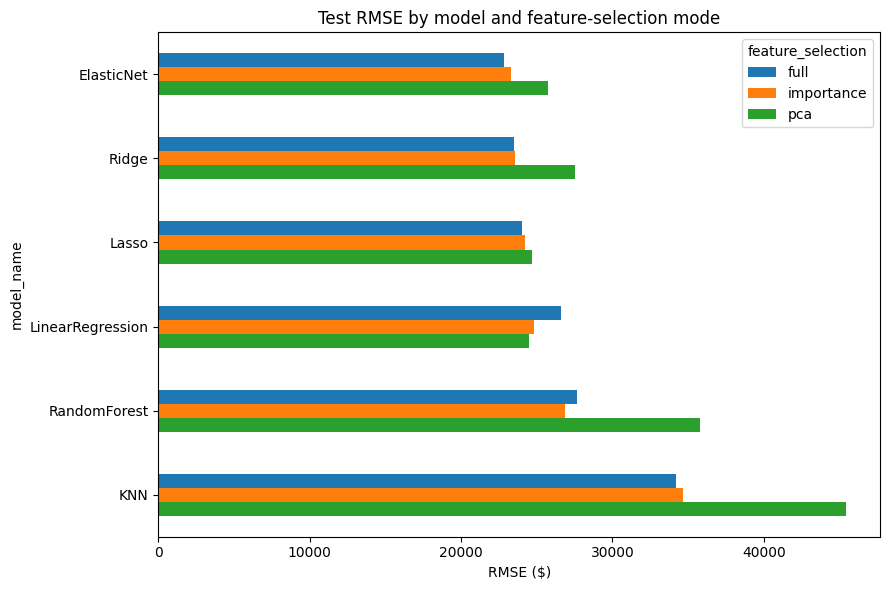

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
pivot = results.pivot(index="model_name", columns="feature_selection", values="rmse_dollars")
pivot = pivot[["full", "importance", "pca"]].sort_values("full")
pivot.plot.barh(ax=ax)
ax.set_xlabel("RMSE ($)")
ax.set_title("Test RMSE by model and feature-selection mode")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Read-off**: ElasticNet on the full feature set is the best
configuration overall (\$22,840 RMSE), with Ridge and Lasso close behind
it in that same round — regularized linear models are the consistent
top performers whenever the feature space still has its original
collinear structure (`full` and `importance`). PCA is the one condition
where that pattern breaks, because it removes the collinearity
regularization was compensating for — but it doesn't produce a better
model overall, since compressing 254 features to 49 components also
throws away real signal, not just redundancy. Practically: if the
feature space is going to be one-hot encoded and only lightly filtered,
reach for ElasticNet/Ridge/Lasso by default; PCA is not a free
accuracy win here, and its main effect is changing *which* model class
wins, not raising the ceiling on any of them.

## Feature importance (RandomForest, full feature set)

Reproduces the original notebook's cells 21-22: fit a RandomForestRegressor
with the same hyperparameters used for importance-based feature selection,
and look at which features it leans on most.

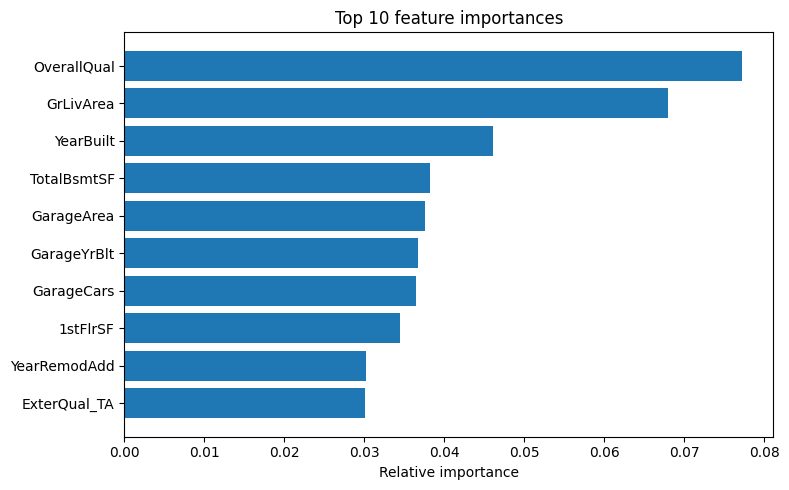

100 features above the 0.001 threshold


OverallQual         0.077282
GrLivArea           0.067982
YearBuilt           0.046097
TotalBsmtSF         0.038253
GarageArea          0.037583
GarageYrBlt         0.036644
GarageCars          0.036419
1stFlrSF            0.034480
YearRemodAdd        0.030242
ExterQual_TA        0.030021
FullBath            0.025777
LotArea             0.023209
Fireplaces          0.022978
BsmtFinSF1          0.021082
FireplaceQu_None    0.019736
dtype: float64

In [8]:
importances = compute_feature_importances(
    trainer_full.prepared.X_train, trainer_full.prepared.y_train, trainer_full.cfg
)

top10 = importances.head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top10.index, top10.values)
plt.xlabel("Relative importance")
plt.title("Top 10 feature importances")
plt.tight_layout()
plt.show()

filtered = importances[importances > trainer_full.cfg.feature_selection.importance.threshold]
print(f"{len(filtered)} features above the {trainer_full.cfg.feature_selection.importance.threshold} threshold")
filtered.head(15)

**Reading the importances**: `OverallQual` and `GrLivArea` are well
ahead of everything else (0.077 and 0.068 vs. 0.046 for the next-highest,
`YearBuilt`) — a subjective 1-10 quality rating and total living area
outweigh any single structural measurement. After those two, the list is
mostly *size* features restated in different forms — `TotalBsmtSF`,
`GarageArea`, `1stFlrSF`, `LotArea` — plus two *age/condition* signals
(`YearBuilt`, `YearRemodAdd`, `GarageYrBlt`) and one categorical dummy
that cracked the top 10 on its own, `ExterQual_TA` (average exterior
quality — its presence this high suggests exterior quality matters enough
that even a single one-hot level of it outweighs most raw numeric
features). This lines up with the correlation ranking from
`00_eda.ipynb`'s heatmap, which is reassuring since the two methods
measure "importance" in unrelated ways — Pearson correlation is a
marginal, linear, single-variable relationship, while RandomForest
importance reflects how much each feature reduces impurity across many
non-linear tree splits conditioned on other features. Agreement between
them is a sign the underlying relationship is fairly linear and
non-redundant, not an artifact of one particular technique.

## PCA explained variance

Reproduces the original notebook's cell 25: how much of the variance in the
254-feature matrix is captured as the number of principal components
grows.

Original number of features: 254
Reduced number of features: 49


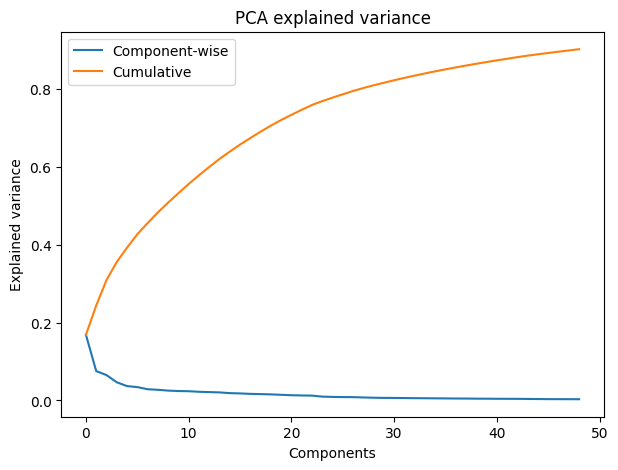

In [9]:
pca = build_pca_reducer(trainer_full.cfg.feature_selection.pca.n_components,
                         trainer_full.cfg.feature_selection.pca.whiten)
X_pca = pca.fit_transform(trainer_full.prepared.X_train)

print("Original number of features:", trainer_full.prepared.X_train.shape[1])
print("Reduced number of features:", X_pca.shape[1])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(range(X_pca.shape[1]), pca.explained_variance_ratio_, label="Component-wise")
ax.plot(range(X_pca.shape[1]), np.cumsum(pca.explained_variance_ratio_), label="Cumulative")
ax.set_xlabel("Components")
ax.set_ylabel("Explained variance")
ax.set_title("PCA explained variance")
ax.legend()
plt.show()

**Reading the curve**: it takes 49 of the theoretically-possible 254
components to reach 90% explained variance — meaning the one-hot-encoded
feature space is nowhere near as information-dense as its raw column
count suggests. That's expected: one-hot encoding turns each categorical
column into several dummy columns that are mutually exclusive by
construction (a house has exactly one `MSZoning` value, so its dummies
are perfectly anti-correlated with each other), and several
quality/condition ratings across different parts of the house tend to
move together (a well-maintained house usually has good `ExterQual`,
`KitchenQual`, and `BsmtQual` all at once). PCA finds and compresses
exactly that redundancy — which is also exactly why it doesn't help
accuracy: the redundancy it's removing was mostly harmless (regularized
linear models already handle collinearity directly), while what's left
after compression is a blend of components that's harder for every model
class to work with than the original, individually-meaningful features
were.